In [1]:

# Import KaggleHub to download the dataset directly from Kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("luisrenterialezano/retail-sales-dataset")

print("Path to dataset files:", path)

c:\Users\Alessia_March\Desktop\progetti_github\.progetti\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Alessia_March\.cache\kagglehub\datasets\luisrenterialezano\retail-sales-dataset\versions\1


In [2]:

# Import the required libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
csv_path = os.path.join(path, csv_files[0])
df = pd.read_csv(csv_path)

data=df.copy() # working copy of the original dataset

# Remove the product description column since I do not consider it usefull for product segmentation and clustering
data=data.drop(["Description"], axis=1)

In [4]:

data["InvoiceDate"] = pd.to_datetime(
    data["InvoiceDate"]) #convert in datetime

# Identify rows containing at least one missing value
missing_rows = data[data.isna().any(axis=1)]
print(missing_rows.shape[0])
# Check whether all missing values are in CustomerID
missing_customer_id = data[data["CustomerID"].isna()]

# Verify if the two subsets are identical. If this is true then CustomerID is the only column with missing values
same_missing_rows = missing_rows.equals(missing_customer_id)

print(same_missing_rows)

# we look to the data with customeID = nan 
data_missing_client = data[data['CustomerID'].isna()]

135080
True


Analysis focused on transactions with missing `CustomerID`. Because in the other files I already analysed the other cases.

## Creation of the dataset for clustering

In [5]:
# Reference date used to compute product recency
max_date = data_missing_client["InvoiceDate"].max()

# co-purchase network using only completed purchases
invoice_products = (
    data_missing_client[data_missing_client["Quantity"] > 0]
    .groupby("InvoiceNo")["StockCode"]
    .apply(set)
)

co_products = {}

for products in invoice_products:
    for p in products:          # uso p per non sovrascrivere product
        if p not in co_products:
            co_products[p] = set()

        co_products[p].update(products - {p})

num_distinct_coproducts = {
    p: len(others)
    for p, others in co_products.items()
}# all distinct products that co-occur with each product across purchase transactions


# List that will store aggregated product-level features
final_rows = []

# Group dataset by product 
product_groups = data_missing_client.groupby("StockCode")

for product, product_data in product_groups:

    product_data = product_data.copy()

    # Separate purchases and returns
    purchases = product_data[product_data["Quantity"] > 0].copy()
    returns = product_data[product_data["Quantity"] < 0].copy()

    # Skip products with no valid purchases
    if len(purchases) == 0:
        continue

    # Compute transaction value
    purchases["TotalValue"] = (
        purchases["Quantity"] * purchases["UnitPrice"]
    )

    returns["TotalValue"] = (
        abs(returns["Quantity"]) * returns["UnitPrice"]
    )

    # Total quantities
    total_quantity_purchased = purchases["Quantity"].sum()
    total_quantity_returned = abs(returns["Quantity"].sum())

    # Number of unique orders containing the product
    num_orders = purchases["InvoiceNo"].nunique()

    # Return ratio
    total_quantity = total_quantity_purchased + total_quantity_returned

    return_ratio = (
        total_quantity_returned / total_quantity
        if total_quantity > 0
        else 0
    )    

    # Recency: days since last purchase
    last_purchase_date = purchases["InvoiceDate"].max()
    recency_days = (max_date - last_purchase_date).days

    # frequency
    order_frequency = num_orders / (recency_days + 1)

    # Total revenue generated by the product
    total_revenue = purchases["TotalValue"].sum()

    # Country entropy (geographical dispersion of demand)
    country_counts = purchases.groupby("Country")["Quantity"].sum()

    if len(country_counts) <= 1:
        country_entropy = 0
    else:
        country_proportions = country_counts / country_counts.sum()
        country_entropy = -np.sum(country_proportions * np.log(country_proportions))
        country_entropy = country_entropy / np.log(len(country_counts))

    # Order timestamps sorted chronologically
    order_dates = (
        purchases.groupby("InvoiceNo")["InvoiceDate"]
        .min()
        .sort_values()
    )

    # Median time between consecutive purchases (in hours)
    if len(order_dates) > 1:
        time_diffs = order_dates.diff().dropna()
        median_time_between_orders = (
            time_diffs.median().total_seconds() / 3600
        )
    else:
        median_time_between_orders = 0

    # Co-purchase ratio: diversity of products bought together,
    # normalized by the number of orders containing the product
    num_distinct_coproducts_ratio = (
        num_distinct_coproducts.get(product, 0) / num_orders
        if num_orders > 0 else 0
    )

    # Store features 
    final_rows.append({
        "StockCode": product,

        "country_entropy": country_entropy,
        "total_quantity_purchased": total_quantity_purchased,
        "total_quantity_returned": total_quantity_returned,
        "median_time_between_orders": median_time_between_orders,
        "num_distinct_coproducts_ratio": num_distinct_coproducts_ratio,
        "num_orders": num_orders,
        "return_ratio": return_ratio,
        "frequency": order_frequency,
        "recency_days": recency_days,
        "total_revenue": total_revenue
    })

# Final dataset for product clustering
product_features = pd.DataFrame(final_rows)

product_features.head()

,StockCode,country_entropy,total_quantity_purchased,total_quantity_returned,median_time_between_orders,num_distinct_coproducts_ratio,num_orders,return_ratio,frequency,recency_days,total_revenue
0,10002,0.0,217,3,69.633333,80.043478,23,0.013636,0.090551,253,60.34
1,10080,0.0,204,0,1593.475000,129.000000,3,0.000000,0.103448,28,4.68
2,10125,0.0,70,0,22.950000,68.766667,30,0.000000,0.476190,62,64.54
3,10133,0.0,483,82,23.833333,33.189189,74,0.145133,0.755102,97,400.61
4,10135,0.0,293,0,23.433333,45.155172,58,0.000000,29.000000,1,420.70


The goal of this phase was to construct a product-level dataset for segmentation purposes, in the case of missing value of the client code.

## Features Constructed for Each Product

For each product identified by its `StockCode`, I constructed ten features describing its sales behavior:

- **total_quantity_purchased**: total quantity purchased.
- **total_quantity_returned**: total quantity returned.
- **total_revenue**: total revenue generated.
- **num_orders**: number of unique orders containing the product.
- **frequency**: orders per day.
- **recency_days**: days since the last purchase, relative to the latest date in the dataset.
- **median_time_between_orders**: median hours between consecutive purchases; low values indicate regular purchases, high values indicate sporadic ones.
- **return_ratio**: ratio of returned quantity to total quantity.
- **country_entropy**: normalized entropy of geographic demand distribution; values near 0 indicate sales concentrated in one country, values near 1 indicate uniform international distribution.
- **num_distinct_coproducts_ratio**: distinct products purchased together / number of orders; high values indicate the product is bought with many different products, low values indicate it is bought alone or always with the same products.


## Correlation Matrix Analysis

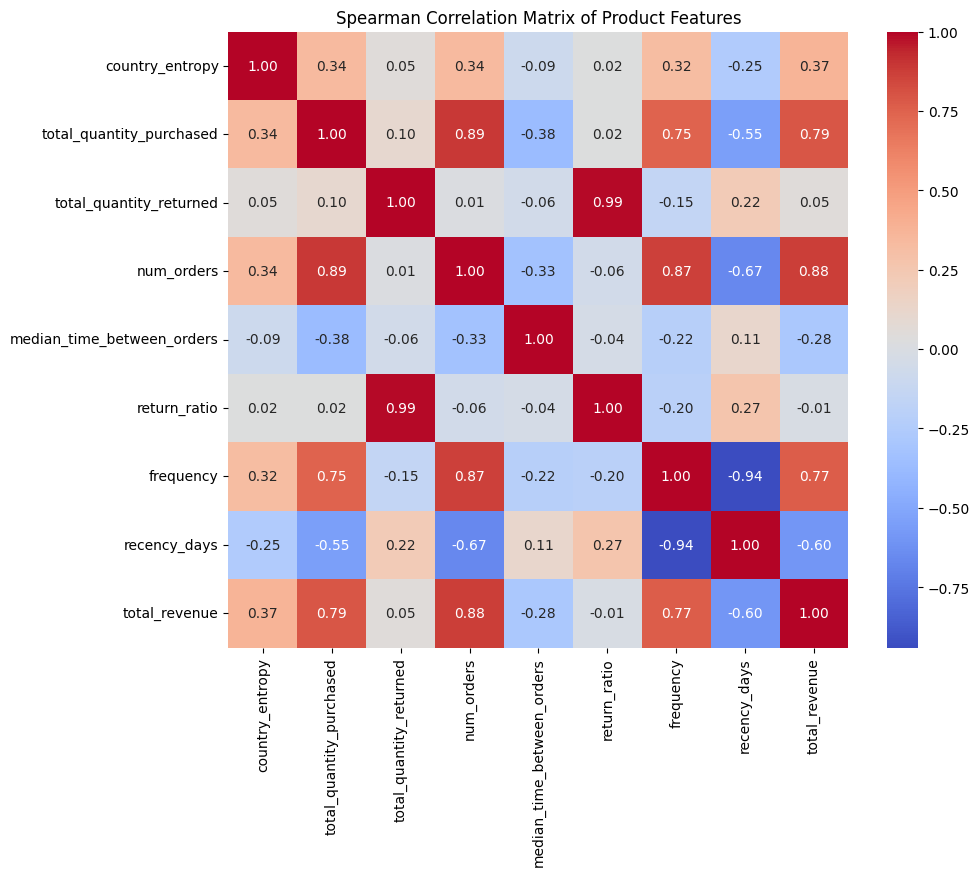

In [6]:
# Features selected for correlation analysis
feature_cols = [
    'country_entropy',
    'total_quantity_purchased',
    "total_quantity_returned",
    'num_orders',
    'median_time_between_orders',
    'return_ratio',
    'frequency',
    'recency_days',
    'total_revenue'
]

# Compute the Spearman correlation matrix.
# Spearman correlation is preferred because several features are highly skewed and may not have a linear relationship.
corr_matrix = product_features[feature_cols].corr(
    method='spearman'
)

# Visualize the correlation matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Spearman Correlation Matrix of Product Features")
plt.show()

I calculated the Spearman correlation matrix, to understand the relationships between the  features and identify potential redundancies. Spearman correlation was preferred over Pearson correlation because several features exhibit highly skewed distributions and non-linear relationships.

**Strong Positive Correlations (> 0.70):**
- **total_quantity_purchased** with **num_orders** (0.89) and **total_revenue** (0.79): products with more orders tend to have higher sales volumes and revenues.
- **num_orders** with **frequency** (0.87) and **total_revenue** (0.88): as expected, products ordered more frequently and by more customers generate higher revenues.
- **frequency** with **total_revenue** (0.77): higher purchase frequency translates into higher revenue generation.
- **total_quantity_returned** with **return_ratio** (0.99): near-perfect correlation, as expected since the return ratio is derived from the returned quantity.

**Strong Negative Correlations (< -0.70):**
- **frequency** with **recency_days** (-0.94): products purchased more recently tend to have a higher purchase frequency.

**Moderate Correlations:**
- **total_quantity_purchased** with **recency_days** (-0.55): products with more recent purchases tend to have higher sales volumes.
- **num_orders** with **recency_days** (-0.67): products with more orders tend to have more recent purchases.
- **total_revenue** with **recency_days** (-0.60): products with higher revenues tend to be purchased more recently. **Weak or Negligible Correlations:**
- **country_entropy** shows weak to moderate correlations with most features (0.32–0.37), suggesting that geographic dispersion is relatively independent of other product characteristics.
- **median_time_between_orders** shows mostly negative but weak correlations (-0.09 to -0.38), indicating that it captures a distinct temporal aspect not strongly correlated with the other metrics.
- **return_ratio** shows very weak correlations with most features (except for total_quantity_returned), suggesting that return behavior is largely independent of other product characteristics.


For the clustering analysis, I retained a subset of six features that capture distinct aspects of product behavior while minimizing redundancy:
- **country_entropy** (geographic dispersion)
- **return_ratio** (product quality)
- **median_time_between_orders** (purchase regularity)
- **recency_days** (temporal recency)
- **total_revenue** (monetary value)
- **frequency** (purchase frequency)

## Data Normalization and Transformation for GMM

In [7]:
features_rfm =['country_entropy',
'return_ratio',
'median_time_between_orders',
'recency_days',
'total_revenue',
]

# Calculate and print skewness of the selected features
# Skewness indicates whether data is symmetrically distributed or has long tails
print(product_features[features_rfm].skew())

country_entropy                2.532239
return_ratio                   2.047841
median_time_between_orders     4.786939
recency_days                   1.701469
total_revenue                 46.496450
dtype: float64


## Preparing the Data for GMM

The features I selected for clustering were all heavily skewed – way above 1. This is particularly evident for `total_revenue` with a skewness of 46.50, where a few products generate extremely high revenue while many generate low revenue. `median_time_between_orders` had a skewness of 4.79, with most products being purchased regularly but a few having huge gaps between orders.

I applied `RobustScaler` – which uses median and IQR instead of mean and standard deviation – so extreme values wouldn't influenced the outcome too much. In addiction, I removed outliers using Mahalanobis distance on a robust covariance matrix, keeping only products within the 95th percentile.

Even after that, some skewness remained. So I applied transformations: `log1p` on `total_revenue`, `recency_days`, and `median_time_between_orders`, and square root on `return_ratio` and `country_entropy`. The distributions became much more symmetric and Gaussian-like.

In [8]:
from sklearn.preprocessing import RobustScaler # RobustScaler uses median and IQR, making it robust to outliers


scaler = RobustScaler()

scaled_data = scaler.fit_transform(product_features[features_rfm])

## Preliminary PCA Analysis

[0.56614017 0.38052508] 0.9466652467530035


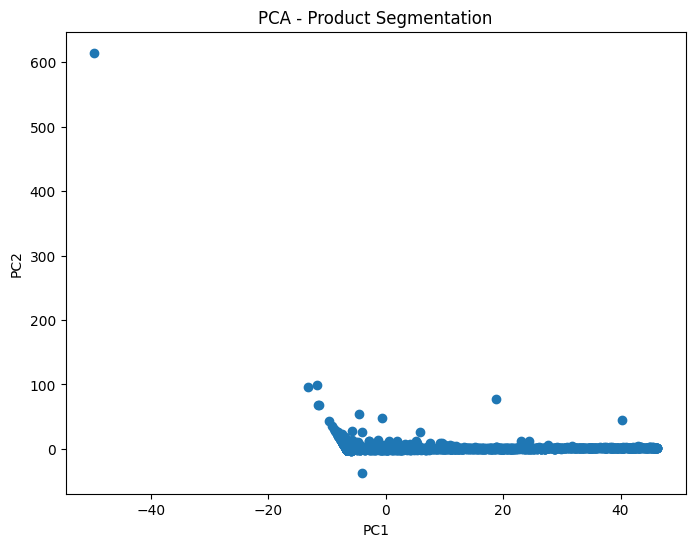

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)# Initialize PCA with 2 components for 2D visualization

X_transformed = pca.fit_transform(scaled_data)

print(pca.explained_variance_ratio_,sum(pca.explained_variance_ratio_))# This shows how much variance is captured by each PC and cumulatively

# Create a figure for the PCA scatter plot
plt.figure(figsize=(8,6))

plt.scatter(
    X_transformed[:, 0],
    X_transformed[:, 1]
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA - Product Segmentation")

plt.show()

I did Principal Component Analysis (PCA) plot to visualize the data structure in a two-dimensional space; this captured **94.7%** of the total variance, thereby preserving almost all the information.

In the resulting scatter plot, certain extreme points deviating significantly from the main distribution are clearly visible. These outliers, located at the edges of the plot, represent products exhibiting anomalous behavior that could distort the clustering analysis.

## Outliers detection 

In [10]:
from sklearn.covariance import MinCovDet
# Detection of outliers by estimating a robust covariance matrix
mcd = MinCovDet(random_state=42)
mcd.fit(scaled_data)

,"store_precision store_precision: bool, default=TrueSpecify if the estimated precision is stored.",True
,"assume_centered assume_centered: bool, default=FalseIf True, the support of the robust location and the covarianceestimates is computed, and a covariance estimate is recomputed fromit, without centering the data.Useful to work with data whose mean is significantly equal tozero but is not exactly zero.If False, the robust location and covariance are directly computedwith the FastMCD algorithm without additional treatment.",False
,"support_fraction support_fraction: float, default=NoneThe proportion of points to be included in the support of the rawMCD estimate. Default is None, which implies that the minimumvalue of support_fraction will be used within the algorithm:`(n_samples + n_features + 1) / 2 * n_samples`. The parameter must bein the range (0, 1].",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines the pseudo random number generator for shuffling the data.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [11]:

# Calculate the Mahalanobis distance for each data point
# It measures how many standard deviations away a point is from the distribution
# It's more robust than Euclidean distance as it accounts for feature correlations

dist = mcd.mahalanobis(scaled_data)

# Set a threshold at the 95th percentile of the Mahalanobis distances
# Points beyond this threshold are considered outliers (top 5% most extreme points)
threshold = np.percentile(dist, 95)

# Create a boolean mask identifying outliers
outliers = dist > threshold 

print("Outliers:", outliers.sum()) # n° of outliers
print("percentage:", outliers.mean() * 100) # % outliers


Outliers: 178
percentage: 5.022573363431151


In [12]:
df_no_outlier = product_features.loc[~outliers].copy() #data without outliers

## Feature Asymmetry After Outlier Removal

In [13]:
# Calculate and print skewness of the selected features
# Skewness indicates whether data is symmetrically distributed or has long tails
print(df_no_outlier[features_rfm].skew())

country_entropy               2.479246
return_ratio                  2.037138
median_time_between_orders    3.241905
recency_days                  1.666829
total_revenue                 3.087252
dtype: float64


The skewness of **total_revenue** improved significantly, after the removal of outliers using Mahalanobis distance. It dropped drastically from 46.50 to 3.09, meaning that the products removed were primarily those with the most anomalous **total_revenue** values.

Skewness values ​​for all features remain above 1, indicating persistent significant positive skewness.

## Feature Transformation for Skewness Reduction

In [14]:
df_clean = df_no_outlier.copy()
cols_log = [
    "total_revenue",
    'recency_days',
    'median_time_between_orders'

]# List of columns to transform with natural logarithm (to reduce skewness), that could cause issues with GMM

for col in cols_log:
    df_clean[col] = np.log1p(df_clean[col])
    
df_clean["return_ratio"] = np.sqrt(df_clean["return_ratio"])

df_clean["country_entropy"] = np.sqrt(df_clean["country_entropy"])

print(df_clean[features_rfm].skew())


country_entropy               1.883672
return_ratio                  1.548493
median_time_between_orders   -0.871579
recency_days                  0.312173
total_revenue                -0.638115
dtype: float64


I applied `log1p` to `total_revenue`, `recency_days`, `median_time_between_orders` and `Square root` to `return_ratio` and `country_entropy`, in order to reduce again the skewness.

The effectiveness of the transformations is evident::
**median_time_between_orders**, **recency_days**, and **total_revenue** approach a nearly symmetrical distribution.
Even if `country_entropy` and `return_ratio` still exhibit slight positive skewness, the overall improvement is significant.
The resulting distributions are now much closer to a Gaussian shape.

## PCA After Outlier Removal and Transformations

[0.70918383 0.16977587] 0.8789597000572245


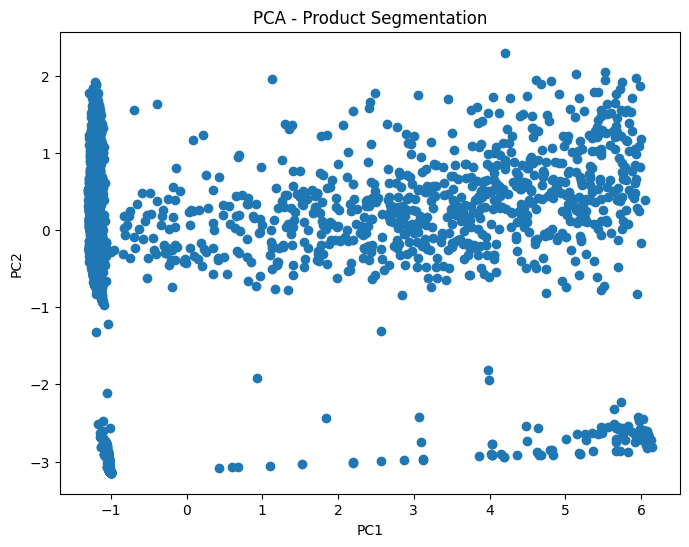

In [15]:
X_clean = df_clean[features_rfm].copy()


scaler_final = RobustScaler()
#scaler_final = StandardScaler()

X_clean_scaled = scaler_final.fit_transform(X_clean)


#new pca plot without outliers
pca_clean = PCA(n_components=2)

pca_df_clean = pca_clean.fit_transform(X_clean_scaled)

print(pca_clean.explained_variance_ratio_,sum(pca_clean.explained_variance_ratio_))

plt.figure(figsize=(8,6))

plt.scatter(
    pca_df_clean[:, 0],
    pca_df_clean[:, 1]
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA - Product Segmentation")

plt.show()


After removing outliers and applying transformations to fix the skewness, I re-standardized the data with `RobustScaler` and ran PCA again.
The first two principal components captured nearly all the information, explaining 94.7% of the total variance.

Looking at the scatter plot, it was possible to see:
- No obvious outliers
- Two main groups emerged that are relatively compact and well-separated, suggesting that products naturally fall into distinct segments. There are also a couple of more dispersed areas that seem to represent products with intermediate or transitional behavior between the main groups.


## Correlation Matrix After Transformations

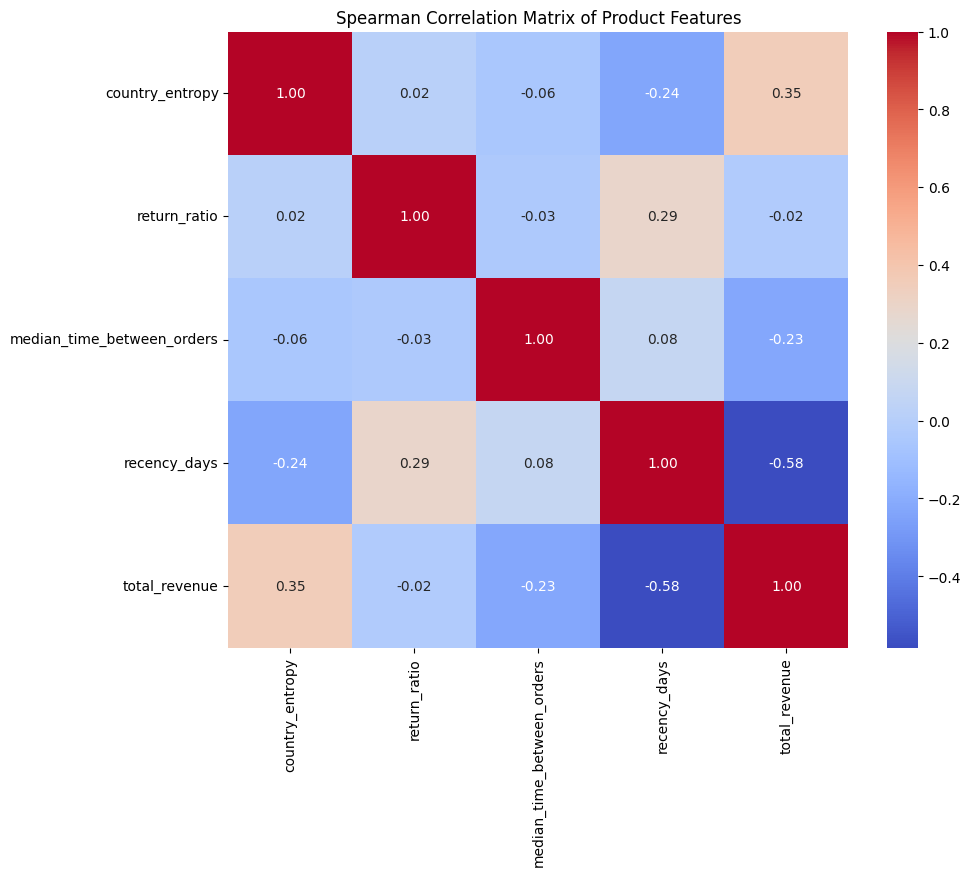

In [16]:

# Calculate the Spearman correlation matrix between the selected features. Using Spearman, the output is not influenced by the logarithm transformation

corr_matrix = df_clean[features_rfm].corr(method='spearman')

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Spearman Correlation Matrix of Product Features")
plt.show()


I re-calculated the Spearman correlation matrix on the remaining features,To check how they relate to each other. There's no major redundancy, which is exactly what you want for clustering.

The only noticeable relationship was a moderate negative correlation between `total_revenue` and `recency_days` (-0.58) – meaning products with higher revenue tend to be purchased more recently. 

Everything else stayed well below 0.36 in absolute value, which confirms that each feature brings its own distinct information to the segmentation. 

# Why I chose the Gaussian Mixture Model (GMM)

GMM assigns each product to a cluster based on **probability**, rather than categorically. That's useful for spotting hybrid products, but in our data, the average assignment confidence turned out to be around 0.99. It also allows to identifying products on the boundary between clusters.

**Flexibility in cluster shape** is another advantage – GMM handles elliptical shapes and correlations between variables, which K-means can't do.
It's also based on maximum likelihood estimation and the EM algorithm. I used BIC to select the optimal number of clusters (8), balancing fit and complexity.

Despite all of that, GMM assumes Gaussian distributions, so I had to transform the data (log and square root) and remove outliers first. Too many clusters can also lead to overfitting, but BIC helped avoid that.


## Selecting the Optimal Number of Clusters Using BIC

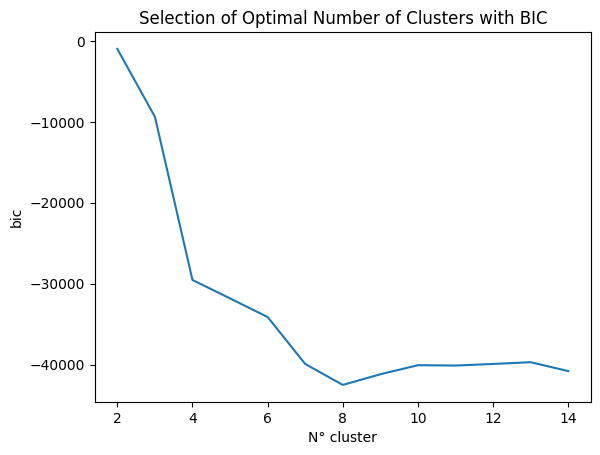

In [18]:
# Import GaussianMixture for model-based clustering
# GMM assumes data is generated from a mixture of Gaussian distributions
from sklearn.mixture import GaussianMixture

bic=[]# BIC is used for model selection - lower values indicate better models

# Define the range of number of components (clusters) to test
n_components_range=range(2,15)


for n in n_components_range:
    # Initialize Gaussian Mixture Model with n components
    gmm = GaussianMixture( n_components=n, random_state=42)
    # Fit the GMM to the scaled clean data
    gmm.fit(X_clean_scaled)
    # Calculate and store the BIC score for this model
    # BIC penalizes model complexity, helping to avoid overfitting
    bic.append(gmm.bic(X_clean_scaled))

# Create a line plot of BIC values vs number of components
plt.plot(n_components_range, bic)
plt.xlabel("N° cluster")
plt.ylabel("bic")
plt.title("Selection of Optimal Number of Clusters with BIC")
plt.show()


In [19]:
best_n = n_components_range[np.argmin(bic)]
print("Numero ottimale cluster:", best_n)

Numero ottimale cluster: 8


Bayesian Information Criterion (BIC) was used to determine the optimal number of cluster; this balances model goodness-of-fit with complexity, penalizing an excessive number of parameters to prevent overfitting.

A range of 2 to 14 components was tested, and the BIC was calculated for each model. The optimal number of clusters corresponds to the value that minimizes the BIC. The minimum BIC value is observed at **8 clusters**—a number that is not excessive, allowing for a sufficiently detailed product segmentation without fragmenting the data into groups that are too small and difficult to interpret.

## Assessment of Cluster Assignment Confidence

count    3366.000000
mean        0.994839
std         0.028676
min         0.503683
25%         0.999916
50%         0.999999
75%         1.000000
max         1.000000
dtype: float64


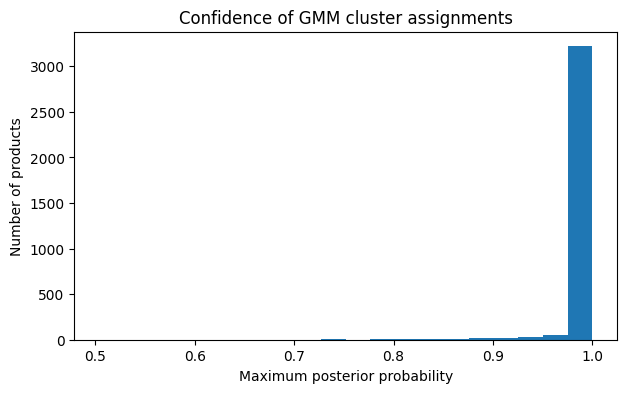

Products with P > 0.99 : 93.6%
Products with P > 0.95 : 97.1%
Products with P > 0.90 : 98.5%
Products with P < 0.70 : 0.2%


In [20]:
# Initialize Gaussian Mixture Model with 10 clusters
gmm = GaussianMixture(
    n_components=8 ,
    random_state=42
)
# Fit the GMM to the scaled clean data and predict cluster labels
labels = gmm.fit_predict(X_clean_scaled)

# Posterior probabilities
probs = gmm.predict_proba(X_clean_scaled)

# Highest probability for each observation
max_probs = probs.max(axis=1)

print(pd.Series(max_probs).describe())

plt.figure(figsize=(7,4))

plt.hist(max_probs, bins=20)

plt.xlabel("Maximum posterior probability")
plt.ylabel("Number of products")
plt.title("Confidence of GMM cluster assignments")

plt.show()


print(f"Products with P > 0.99 : {(max_probs > 0.99).mean()*100:.1f}%")
print(f"Products with P > 0.95 : {(max_probs > 0.95).mean()*100:.1f}%")
print(f"Products with P > 0.90 : {(max_probs > 0.90).mean()*100:.1f}%")
print(f"Products with P < 0.70 : {(max_probs < 0.70).mean()*100:.1f}%")

For each product I looked at the posterior probabilities, to see how likely it is to belong to its assigned cluster. I took the maximum probability and plotted the distribution.

The histogram was heavily skewed toward 1, meaning that most products were placed in their cluster with very high confidence – the average probability came out to 0.995, with a standard deviation of just 0.029. When probabilities are this high across the board, the clusters are  distinct from each other. 

There's also very little uncertainty – only about 0.2% of products had a confidence level below 0.70, so almost everything was classified without any real ambiguity.

## Cluster Visualization

## PCA Projection

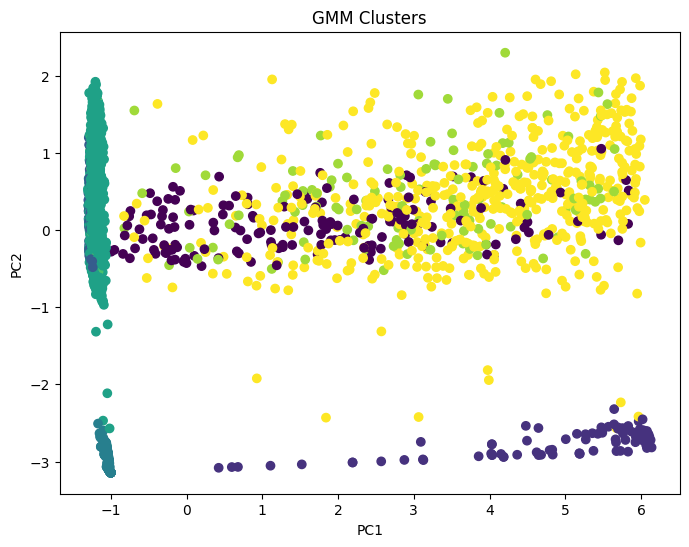

In [21]:
# Plot pca, colored by cluster assignment

plt.figure(figsize=(8,6))

plt.scatter(
    pca_df_clean[:,0],
    pca_df_clean[:,1],
    c=labels
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("GMM Clusters")

plt.show()

The PCA projection of the data, colored according to cluster assignments, reveals an overall well-defined structure, although some overlap between adjacent clusters is observed. This overlap is inherent to a probabilistic model like GMM, where clusters are represented by Gaussian distributions that can intersect in certain boundary areas—as seen with the yellow, purple and green clusters. Nevertheless, many points are clearly attributable to specific clusters (specifically, the two clusters in the left area and the one at the bottom).

Clusters with zero-return customers: [4 5 3 2]


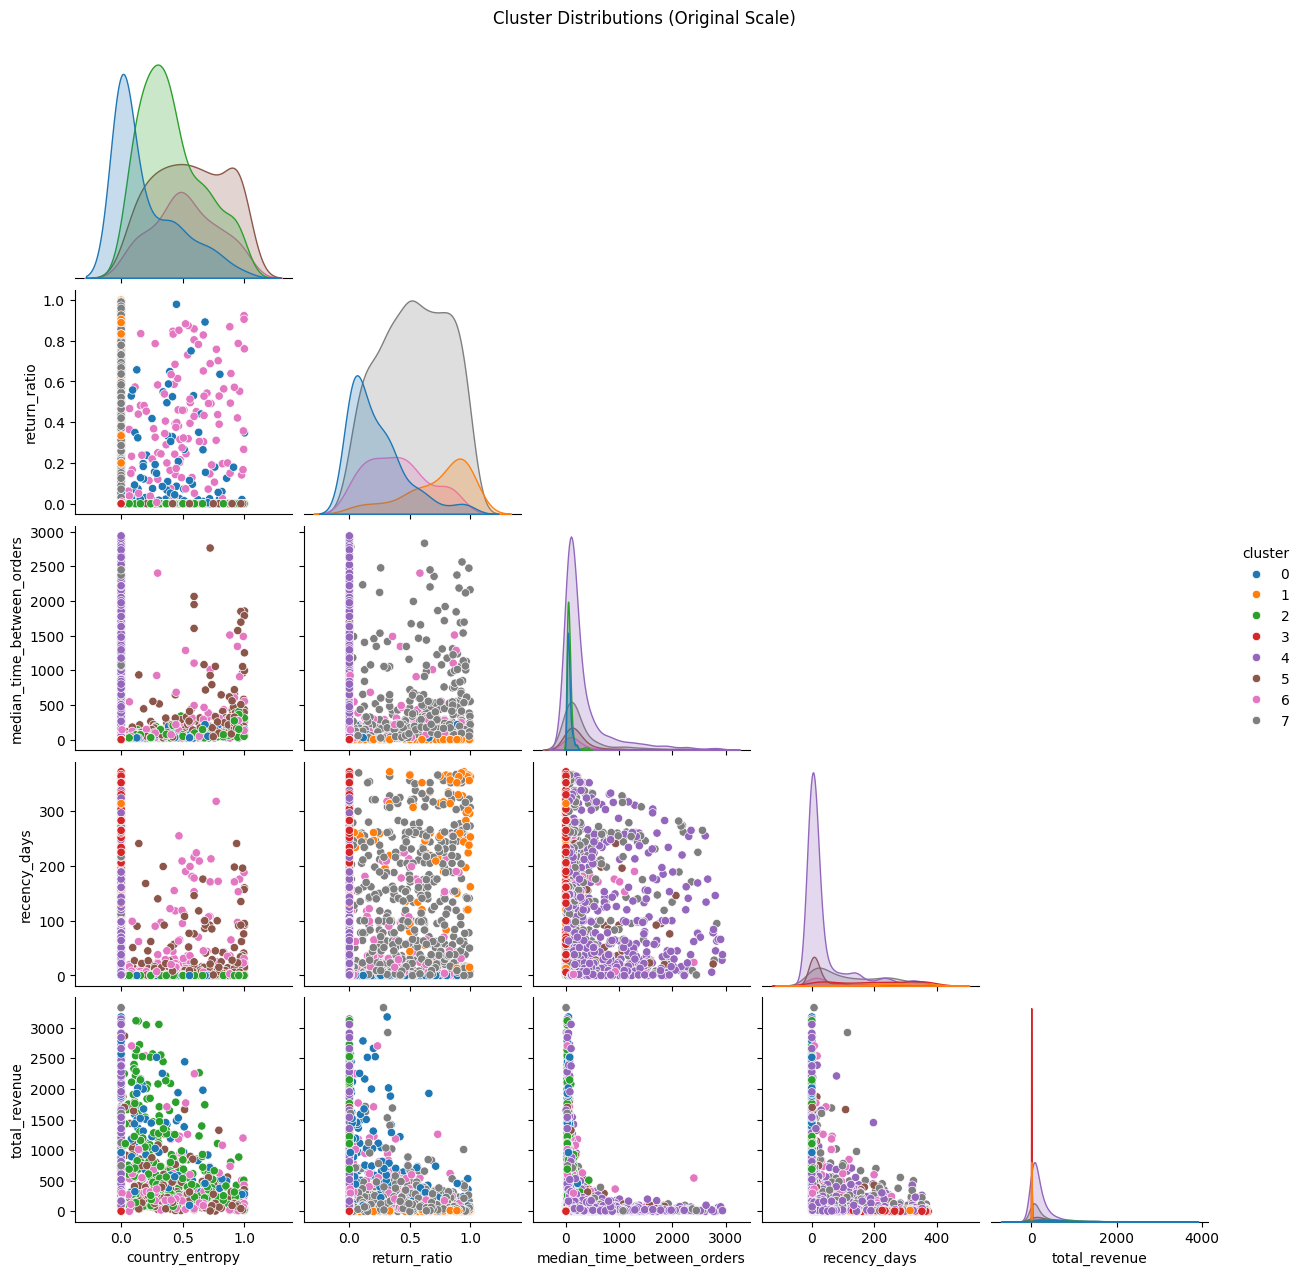

In [22]:
# Create dataframe with ORIGINAL (back-transformed) values and cluster assignments
# back-transform log-transformed values to original scale
df_backtransformed = df_clean.copy()
for col in cols_log:
    df_backtransformed[col] = np.expm1(df_backtransformed[col])

df_backtransformed["return_ratio"]=df_backtransformed["return_ratio"]**2
df_backtransformed["country_entropy"]=df_backtransformed["country_entropy"]**2

df_backtransformed["cluster"] = labels

# Check if any cluster consists only of customers with zero returns
print("Clusters with zero-return customers:", 
      df_backtransformed[df_backtransformed["return_ratio"] == 0]["cluster"].unique())

# pairplot with original scale values
sns.pairplot(
    df_backtransformed,
    vars=features_rfm,  # These are now in original scale
    hue="cluster",
    palette="tab10",
    corner=True
)
plt.suptitle("Cluster Distributions (Original Scale)", y=1.02)
plt.show()




Some features show good separation between clusters, while others exhibit partially overlapping distributions: **total_revenue** and **recency_days** emerge as the most discriminating variables, whereas **country_entropy** and **return_ratio** show greater overlap between clusters.

Clusters 2, 3, 4, and 5 include products with a **return_ratio** of zero, distinguishing them from the other clusters by the absence of returns. 

## Cluster Profiles

In [23]:
cluster_sizes = df_backtransformed.groupby("cluster").size().rename("cluster_size")

# median values for all features
cluster_medians = df_backtransformed.groupby("cluster")[features_rfm].median().round(2)

# mean values for all features
clusters_mean= df_backtransformed.groupby("cluster")[features_rfm].mean().round(2)

original_clusters_median = pd.concat([cluster_sizes, cluster_medians], axis=1)

print("\nCluster profiles (median values - original scale):")
print(original_clusters_median)

original_clusters_mean = pd.concat([cluster_sizes, clusters_mean], axis=1)

print("\nCluster profiles (mean values - original scale):")
print(original_clusters_mean)


Cluster profiles (median values - original scale):
         cluster_size  country_entropy  return_ratio  \
cluster                                                
0                 168             0.04          0.16   
1                  84             0.00          0.83   
2                 257             0.37          0.00   
3                 229             0.00          0.00   
4                1786             0.00          0.00   
5                 215             0.55          0.00   
6                 117             0.50          0.38   
7                 510             0.00          0.53   

         median_time_between_orders  recency_days  total_revenue  
cluster                                                           
0                             47.65           0.0         589.58  
1                              0.00         260.5           2.53  
2                             48.25           0.0         532.54  
3                              0.00         204.0   

To characterize the eight identified clusters, I analysed the medians of the original features and the size of each group.

**Cluster 4** is the largest, comprising over half of the products, and represents the "standard" segment: products with average revenue, recent purchases, and no returns. **Cluster 2** also identifies high-performing products, characterized by high revenue, recent purchases, and a zero return rate.

**Clusters 0** and **6** comprise higher-value products. Cluster 0 consists of niche products—predominantly domestic—with high revenue and a moderate return rate, whereas Cluster 6 is characterized by a stronger international presence, high revenue, and a significant return rate.

**Cluster 5** stands out primarily for its high level of internationalization, while maintaining intermediate revenue, recent purchases, and no returns.

**Clusters 1** and **7** represent the most problematic segments, sharing high return rates and a longer time elapsed since the last purchase. Specifically, Cluster 1 is the smallest and shows very low revenue, while Cluster 7 includes a larger number of products with low-to-medium revenue.

Finally, **Cluster 3** groups together low-value niche products, characterized by low revenue, no returns, and limited recent activity.


## Outlier Analysis

In [24]:
# Create a DataFrame with only outlier rows for analysis
df_outliers = product_features[outliers].copy()
df_outliers['distanza_mahalanobis'] = dist[outliers]



# 1. HOW MANY OUTLIERS ARE THERE?
print(f"Outlier: {outliers.sum()} over {len(product_features)} products ({outliers.mean()*100:.1f}%)")

# 2. WHAT MAKES THEM DIFFERENT? (compare medians)
print("\n" + "="*50)
print("COMPARISON (median)")
print("="*50)

#compare normal vs outlier
for col in features_rfm:

    normale = product_features.loc[~outliers, col].median()

    outlier_val = df_outliers[col].median()
    
    # Categorize outliers based on how different they are
    if outlier_val > normale * 2:
        
        print(f"{col}: HIGHER OUTLIER ({outlier_val:.1f} vs {normale:.1f})")# Outliers have values more than double the normal median
    elif outlier_val < normale / 2:
        
        print(f"{col}: LOWER OUTLIER ({outlier_val:.1f} vs {normale:.1f})")# Outliers have values less than half the normal median
    else:
        
        print(f"{col}: similar ({outlier_val:.1f} vs {normale:.1f})")# Outliers are relatively similar to normal customers

print("\n" + "="*50)
print("TYPES OF OUTLIERS")
print("="*50)

# Count high-spending outliers (top 5% of spending)
print(f" products with spending > 95th percentile: {(df_outliers['total_revenue'] > product_features['total_revenue'].quantile(0.95)).sum()}")

# Count products with high return ratio (>50%)
print(f" products with many returns (>50%): {(df_outliers['return_ratio'] > 0.5).sum()}")

# Count of products with >1 year since last purchase
print(f" product with >1 year last purchase: {(df_outliers['recency_days'] > 365).sum()}")


Outlier: 178 over 3544 products (5.0%)

COMPARISON (median)
country_entropy: similar (0.0 vs 0.0)
return_ratio: similar (0.0 vs 0.0)
median_time_between_orders: HIGHER OUTLIER (3120.6 vs 92.5)
recency_days: LOWER OUTLIER (3.0 vs 7.0)
total_revenue: LOWER OUTLIER (44.1 vs 121.5)

TYPES OF OUTLIERS
 products with spending > 95th percentile: 79
 products with many returns (>50%): 23
 product with >1 year last purchase: 0


These cases were removed to prevent extreme observations from influencing cluster estimation and compromising the stability of the **Gaussian Mixture Model**. Although excluded from the clustering analysis, these products remain a case of interest.

The analysis identified **178 outliers** out of **3,544 products** (5.0% of the sample), a percentage consistent with the adopted threshold (95%). Compared to the remaining products, the outliers exhibit much longer intervals between orders, lower average **recency** (indicating more recent purchases), and lower median revenues. Conversely, **country_entropy** and **return_ratio** show median values ​​similar to those observed in the rest of the sample.

Notable among the outliers are **79 products** with revenues exceeding the 95th percentile of the distribution and **23 products** with a return rate above 50%, highlighting the presence of both exceptionally high-performing products and products characterized by potentially problematic behavior.
